In [33]:
import os
import matplotlib.pyplot as plt
import numpy as np

import awkward as ak
import coffea
from coffea.nanoevents import NanoEventsFactory, BaseSchema, NanoAODSchema
from coffea.nanoevents.methods import candidate
from coffea.dataset_tools import apply_to_fileset, max_chunks, max_files, preprocess

from coffea import processor
from coffea.processor.accumulator import column_accumulator
from helpers import gen_higgs_parentage

import dask
import uproot

import json
import pickle
import xgboost as xgb

In [34]:
class BDTFeatureExtractor(processor.ProcessorABC):
    def __init__(self, tagger, signal_label="signal", background_label="background"):
        self.signal_label = signal_label
        self.background_label = background_label
        self.tagger = tagger
    def process(self, events):
        is_signal = events.metadata.get('isSignal', False)

        # must pass parking trigger
        events = events[events.HLT.Mu10_Barrel_L1HP11_IP6] 

        # mark jets with a triggerable muon
        jets = events.Jet; muons = events.Muon
        parkingMuonMask = (muons.pt > 11) & (abs(muons.eta) < 0.9) 
        trigMuons = muons[(muons.triggerIdLoose) & parkingMuonMask]
        jets = ak.with_field(jets, jets.deltaR(jets.nearest(trigMuons))<0.4, where="hasTrigMuon")

        # signal is just bjets matched to a higgs; background is all combinations
        if is_signal:
            # get b-partons with a higgs ancestor
            gens = events.GenPart
            bgens = gens[(abs(gens.pdgId) == 5)]
            bgens_higgs = bgens[bgens.distinctParent.pdgId == 25]

            # match b jets to higgs matched partons
            bjets = jets[abs(jets.partonFlavour) == 5]
            matching_higgs_parton = ~ak.is_none(bjets.nearest(bgens_higgs, threshold=0.4), axis=1)
            bjets["matchedHiggs"] = matching_higgs_parton
            input_jets = bjets[bjets.matchedHiggs]
        else:
            input_jets = jets

        # make all pairs that contain at least one triggerable muon
        pairs = ak.combinations(input_jets, 2, fields=["j1", "j2"])
        pairs = ak.drop_none(pairs[pairs.j1.hasTrigMuon | pairs.j2.hasTrigMuon])

        # get BDT features
        dijet = pairs.j1 + pairs.j2
        jet_1 = pairs.j1
        jet_2 = pairs.j2

        dijet_pt = dijet.pt

        jet1_pt = jet_1.pt;                      jet2_pt = jet_2.pt
        jet1_eta = jet_1.eta;                    jet2_eta = jet_2.eta    
        jet1_phi = jet_1.phi;                    jet2_phi = jet_2.phi
        if self.tagger == "DeepJet":
            jet1_btag = jet_1.btagDeepFlavB;         jet2_btag = jet_2.btagDeepFlavB
        else:
            try: jet1_btag = jet_1.btagRobustParTAK4B;         jet2_btag = jet_2.btagRobustParTAK4B
            except:jet1_btag = jet_1.btagUParTAK4B;                  jet2_btag = jet_2.btagUParTAK4B

                
        features = {
            'jet1_pt': ak.flatten(jet1_pt), 'jet2_pt': ak.flatten(jet2_pt),
            'jet1_eta': ak.flatten(jet1_eta), 'jet2_eta': ak.flatten(jet2_eta),
            'jet1_phi':     ak.flatten(jet1_phi), 'jet2_phi': ak.flatten(jet2_phi),
            'jet1_btag': ak.flatten(jet1_btag), 'jet2_btag': ak.flatten(jet2_btag),
        } 

        dijet_array = ak.flatten(dijet_pt)
        total_pairs = ak.num(dijet_array, axis=0)
        n_events = ak.num(events, axis=0)

        if is_signal:
            labels_flat = ak.ones_like(dijet_array)
        else:        
            labels_flat = ak.zeros_like(dijet_array)

        return {
            'features': {k: column_accumulator(v) for k, v in features.items()},
            'labels': column_accumulator(labels_flat),
            'n_events': n_events,
            'n_pairs': total_pairs
        }        
    def postprocess(self, accumulator):
        pass


In [35]:
def numpyify(output_dict):
    feature_arrays = []
    label_arrays = []

    feature_names = [
        'jet1_pt', 'jet2_pt', 
        'jet1_eta', 'jet2_eta',
        'jet1_phi', 'jet2_phi',
        'jet1_btag', 'jet2_btag',
    ]

    features = output_dict['features']
    labels = output_dict['labels']
    
    feature_array = np.column_stack([ak.to_numpy(features[name].value) for name in feature_names])
    
    label_array = ak.to_numpy(labels.value)        
    feature_arrays.append(feature_array)
    label_arrays.append(label_array)
    
    X = np.vstack(feature_arrays)
    y = np.hstack(label_arrays)
    
    return X, y, feature_names


In [36]:
signal_fileset_full = {"/Private/HiggsToBB/ggF/Sum24_1mil_ggF": 
 {
    "files": {"./higgs125_bb_ggF_v15.root": "Events"},
    "metadata": {"isSignal": True, "isMC": True,"short_name": "signalggF"}
 }
}
signal_fileset_mu = {"/Private/HiggsToBB/ggF/Sum24_1mil_gg_muF": 
 {
    "files": {"./higgs125_bb_ggF__muFilter_v15.root": "Events"},
    "metadata": {"isSignal": True, "isMC": True,"short_name": "signalggFMu"}
 }
}
qcd_fileset = {"/Private/HiggsToBB/QCD/Sum24_1mil_QCD": 
   {
    "files": {"./QCD_bb_inclusive_v15.root": "Events"},
    "metadata": {"isSignal": False, "isMC": True,"short_name": "backgroundQCD"}
   }
}
background_fileset = {"/ParkingSingleMuon0/Run2024B-PromptReco-v1/NANOAOD": 
 {
    "files": {
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/981/00000/9bc5764d-1d22-41d1-ac50-52a16aab6242.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/985/00000/a1bac08b-a0fc-4bbf-976c-7ebbc86d4ef0.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/993/00000/ebfeb1a1-ffbd-4287-bb0b-da4655a2ed32.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/994/00000/66edd28e-e731-4615-a79e-53c6e70dab34.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/995/00000/5ef0f348-3e71-4f87-a858-8902a0009e89.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/996/00000/4388bd63-3c16-40eb-8ee9-b544b0fb2292.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/997/00000/fb50fe91-0a48-46f9-a932-53945b4e4a25.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/998/00000/9aaad93f-2956-4a86-b114-a4dd384fbed3.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/999/00000/64ff3414-b1f4-4f24-8f02-75af115e715e.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/000/00000/fe64c7e3-4a8e-4cf0-9f14-099ea51bf3e8.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/001/00000/933fb5c5-1bfd-471f-b51e-7d065f3a03c7.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/002/00000/c9a51298-009b-43c6-9abd-2c688a0fcee7.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/003/00000/850233be-723e-4dc7-9f68-0e3c96b01100.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/004/00000/013edca2-be7d-4390-b70b-2a25d4982ce4.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/005/00000/56e4b734-c67d-44f4-acee-d47f625523a2.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/006/00000/7c84a04d-2e82-4308-a48d-249c96d17829.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/007/00000/d97a316f-3792-4dda-9df3-e4d7693c6657.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/008/00000/9e3cc8dc-517c-42cc-bfe9-cac5b155bfdf.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/009/00000/663bb252-f54f-40d8-91b3-8f46f24213c5.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/010/00000/2365ccf1-432b-4bf4-b9e5-d2f470d780fa.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/011/00000/9bdb1d35-f0db-4899-9926-21a543ec5f8d.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/012/00000/7029456c-1e08-4c9f-b687-7019d0e8cf73.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/028/00000/bd9a1dd3-046b-4fdc-baae-213b1a9660f7.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/029/00000/ea19ba07-1b6c-48e9-80e8-934956a79e6c.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/031/00000/b941ae56-3d13-4c11-b5b2-d4cf0a8e738f.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/058/00000/75ab83c1-9b9f-4892-8c47-15b1c86691f9.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/075/00000/49eab3d4-3283-447b-9f53-02d1045134a6.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/154/00000/894bd188-ded2-4a47-8e5a-a835274a451d.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/238/00000/aa550ca3-4c6e-4595-8fa0-7de4039088f3.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/243/00000/4bc1d91a-8240-4d2f-a7a0-2df3a0615540.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/252/00000/0b6f4bcc-877c-4ee7-bf50-1ba0e30d7175.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/252/00000/9d7348e8-596d-47db-b541-85904ece1ca0.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/253/00000/67d395fb-8fb8-4191-b621-29c28d42ac3e.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/338/00000/41042ef4-8802-48b4-b664-a233be09f2ef.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/349/00000/43e07ad6-2b15-4b25-90b5-5c7de7bcb92e.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/350/00000/e023d2ed-81bf-4fda-b80e-6256f689f622.root": "Events",
      "root://cmseos.fnal.gov//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/379/355/00000/59543a9d-e235-4e95-8a05-9fea635d22be.root": "Events",
    },
    "metadata": {"isSignal": False, "isMC": False, "short_name": "SingleMuon24B0"}
  }
}
signal_fileset = signal_fileset_full | signal_fileset_mu
training_fileset = signal_fileset | background_fileset

In [ ]:
runner = processor.Runner(
     executor = processor.IterativeExecutor(),
     savemetrics=True,
     schema=NanoAODSchema,
     chunksize=100000,
     skipbadfiles=True,
     align_clusters=True,
)
output, metrics = runner(training_fileset, processor_instance=BDTFeatureExtractor(tagger="DeepJet"))

X, y, feature_names = numpyify(output)
print(f"signal candidates: {np.sum(y == 1)}")
print(f"background candidates: {np.sum(y == 0)}")
print(f'{X.shape[1]} features = {feature_names}')

Output()

Output()

signal candidates: 49062
background candidates: 1662187
8 features = ['jet1_pt', 'jet2_pt', 'jet1_eta', 'jet2_eta', 'jet1_phi', 'jet2_phi', 'jet1_btag', 'jet2_btag']


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training on {len(X_train)} dijets")
print(f"Testing on {len(X_test)} dijets")

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 4,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0.1,
    'random_state': 42,
    'tree_method': 'hist'
}
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

print("Starting training ...")
model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=xgb_params['n_estimators'],
    evals=[(dtrain, 'train'), (dtest, 'test')],
    early_stopping_rounds=10,
    verbose_eval=10,
)

Training on 1368999 dijets
Testing on 342250 dijets
Starting training ...


/uscms/home/ccosby/.local/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [05:23:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	train-auc:0.90324	test-auc:0.90569
[10]	train-auc:0.96836	test-auc:0.96877
[20]	train-auc:0.97237	test-auc:0.97280
[30]	train-auc:0.97463	test-auc:0.97510
[40]	train-auc:0.97585	test-auc:0.97638
[50]	train-auc:0.97701	test-auc:0.97758
[60]	train-auc:0.97784	test-auc:0.97838
[70]	train-auc:0.97850	test-auc:0.97902
[80]	train-auc:0.97918	test-auc:0.97967
[90]	train-auc:0.97982	test-auc:0.98027
[100]	train-auc:0.98033	test-auc:0.98073
[110]	train-auc:0.98085	test-auc:0.98123
[120]	train-auc:0.98117	test-auc:0.98152
[130]	train-auc:0.98145	test-auc:0.98175
[140]	train-auc:0.98171	test-auc:0.98195
[150]	train-auc:0.98192	test-auc:0.98211
[160]	train-auc:0.98222	test-auc:0.98238
[170]	train-auc:0.98243	test-auc:0.98255
[180]	train-auc:0.98270	test-auc:0.98278
[190]	train-auc:0.98292	test-auc:0.98298
[199]	train-auc:0.98313	test-auc:0.98314


test AUC: 0.9831


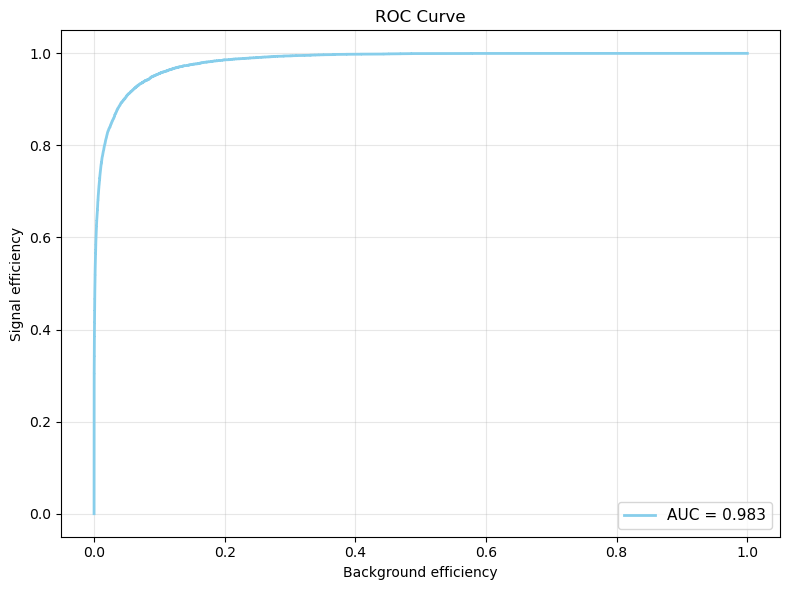

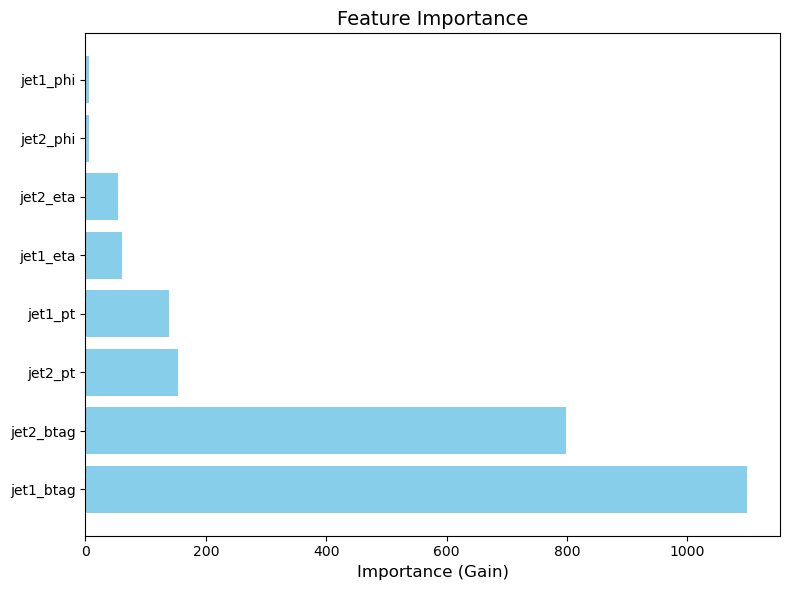

In [7]:
y_pred_test = model.predict(dtest)

auc_test = roc_auc_score(y_test, y_pred_test)
print(f"test AUC: {auc_test:.4f}")

fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, label=f'AUC = {auc_test:.3f}', linewidth=2, color='skyblue')
plt.xlabel('Background efficiency')
plt.ylabel('Signal efficiency')
plt.title('ROC Curve')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

importance = model.get_score(importance_type='gain')
feature_importance = [(feature_names[int(k[1:])], v) for k, v in importance.items()]
feature_importance.sort(key=lambda x: x[1], reverse=True)

plt.figure(figsize=(8, 6))
features_sorted, importances_sorted = zip(*feature_importance)
plt.barh(range(len(features_sorted)), importances_sorted, color='skyblue')
plt.yticks(range(len(features_sorted)), features_sorted)
plt.xlabel('Importance (Gain)', fontsize=12)
plt.title('Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

In [92]:
model_filename = "models/bdt_model_DeepJet_noDijet_info.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)


feature_dict = {'feature_names': feature_names, 'n_features': len(feature_names)}
feature_dump = "models/bdt_feature_names.pkl"
with open(feature_dump, 'wb') as f:
    pickle.dump(feature_dict, f)

In [ ]:
import hist
import dask
from hist import Hist, NamedHist
from hist.dask import Hist as DaskHist
from coffea import processor

class BDTTestProcessor(processor.ProcessorABC):
    def __init__(self, xgbmodel, tagger):
        self.model = xgbmodel
        self.tagger = tagger

    def process(self, events):
        is_signal = events.metadata.get('isSignal', False)

        # must pass parking trigger
        events = events[events.HLT.Mu10_Barrel_L1HP11_IP6] 
        jets = events.Jet    

        # signal is just bjets matched to a higgs; background is all combinations
        if is_signal:
            # get b-partons with a higgs ancestor
            gens = events.GenPart
            bgens = gens[(abs(gens.pdgId) == 5)]
            bgens_higgs = bgens[bgens.distinctParent.pdgId == 25]

            # match b jets to higgs matched partons
            bjets = jets[abs(jets.partonFlavour) == 5]
            matching_higgs_parton = ~ak.is_none(bjets.nearest(bgens_higgs, threshold=0.6), axis=1)
            bjets["matchedHiggs"] = matching_higgs_parton
            jets = bjets[bjets.matchedHiggs]
        else: # if data, mask all but 5% of events
            events = events[events.event%20 == 0]


        dijet_hist = (Hist.new.Reg(150, 50, 350, name="dijetmass", label="$m_{jj}$ [GeV]")
                              .Reg(12, 0, 300, name="dijetpt", label="$p_{T}$ [GeV]")
                              .Reg(200, 0, 1, name="bdt", label="BDT score")
                              .Reg(10, 0, 100, name="subleading_pt", label="$p_{T}$ [GeV]").Double())

        
        pairs = ak.combinations(jets, 2, fields=["b1", "b2"])
                
        dijet = pairs.b1 + pairs.b2
        
        jet1 = pairs.b1;                    jet2 = pairs.b2
        jet1_pt = jet1.pt;                  jet2_pt = jet2.pt

        lower_pt = ak.where(jet1_pt < jet2_pt, jet1_pt, jet2_pt)  

        jet1_eta = jet1.eta;                jet2_eta = jet2.eta    
        jet1_phi = jet1.phi;                jet2_phi = jet2.phi

        jet1_btag = None;                   jet2_btag = None
        if self.tagger == "DeepJet": 
            jet1_btag = jet1.btagDeepFlavB    
            jet2_btag = jet2.btagDeepFlavB
        elif self.tagger == "UParT":  
            try:
                jet1_btag = jet1.btagRobustParTAK4B      
                jet2_btag = jet2.btagRobustParTAK4B
            except: 
                jet1_btag = jet1.btagUParTAK4B
                jet2_btag = jet2.btagUParTAK4B
        

        features = np.stack(
            [
            ak.flatten(jet1_pt), ak.flatten(jet2_pt),
            ak.flatten(jet1_eta), ak.flatten(jet2_eta),
            ak.flatten(jet1_phi), ak.flatten(jet2_phi),
            ak.flatten(jet1_btag), ak.flatten(jet2_btag),
            ], axis=-1
        )
        
        features = ak.to_numpy(features)
        dmatrix = xgb.DMatrix(features)
        scores = self.model.predict(dmatrix)
        dijet["score"] = ak.unflatten(scores, ak.num(dijet))


        
        dijet_hist.fill(
            dijetmass=ak.flatten(dijet.mass),
            dijetpt=ak.flatten(dijet.pt),
            bdt=ak.flatten(dijet.score),
            subleading_pt=ak.flatten(lower_pt)
        )


        return {
            "entries": ak.num(events, axis=0),
            "dijet_hist": dijet_hist
        }
    
    def postprocess(self, accumulator):
        pass

In [ ]:
iterative_run = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=NanoAODSchema,
    # maxchunks=3,
    savemetrics=True,
)
hists = []
for sample in [signal_fileset, signal_fileset_mu, background_fileset]:
    out, metrics = iterative_run(
        sample,
        processor_instance=BDTTestProcessor(model),
    )
    hists.append(out['dijet_hist'])

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [ 0:00:33 < 0:00:00 | 0.5 chunk/s ]

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ 0:00:08 < 0:00:00 | 0.6 chunk/s ]

Preprocessing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 [ 0:00:00 < 0:00:00 | ? file/s ]

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48/48 [ 0:02:01 < 0:00:00 | 0.1 chunk/s ]

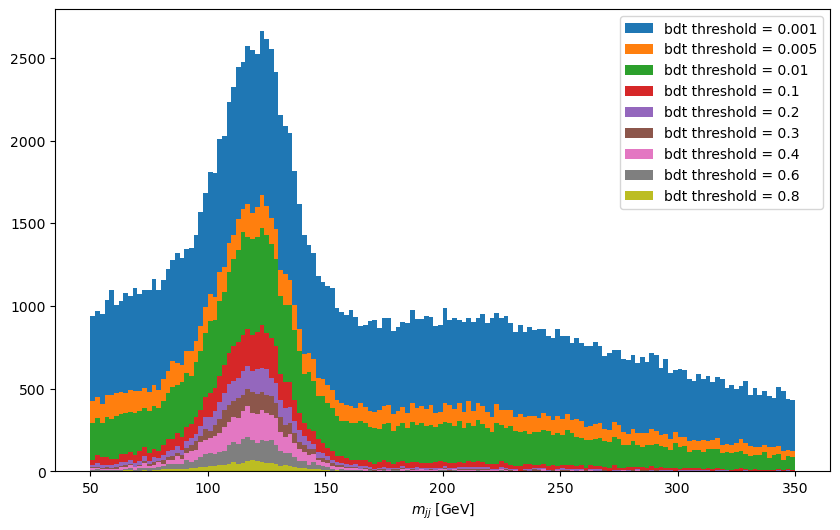

In [86]:
import matplotlib.colors as colors
import matplotlib

sig_hist = hists[0]
# hist_3d.project("dijetmass", "dijetpt").plot2d(norm=matplotlib.colors.LogNorm())
# hist_3d.project("bdt").plot1d()

# for i, axis in enumerate(hist_2d.axes):
#     fig, ax = plt.subplots(figsize=(10, 6)) 
#     hist_2d.project(axis.name).plot1d(ax=ax, fill=True, label=axis.name, color=plt.colormaps['Set1'](i), flow='none')
#     plt.show()
fig, ax = plt.subplots(figsize=(10, 6)) 
bdt_values = [0.001, 0.005, 0.01, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]
for i in bdt_values:
    x = complex(0, i)
    sig_hist[:, 100j:300j:sum, x:1.0j:sum, 50j::sum].plot1d(ax=ax, fill=True, label=f"bdt threshold = {i}", flow='none')
# ax.set_yscale('log')
plt.legend()
plt.show()

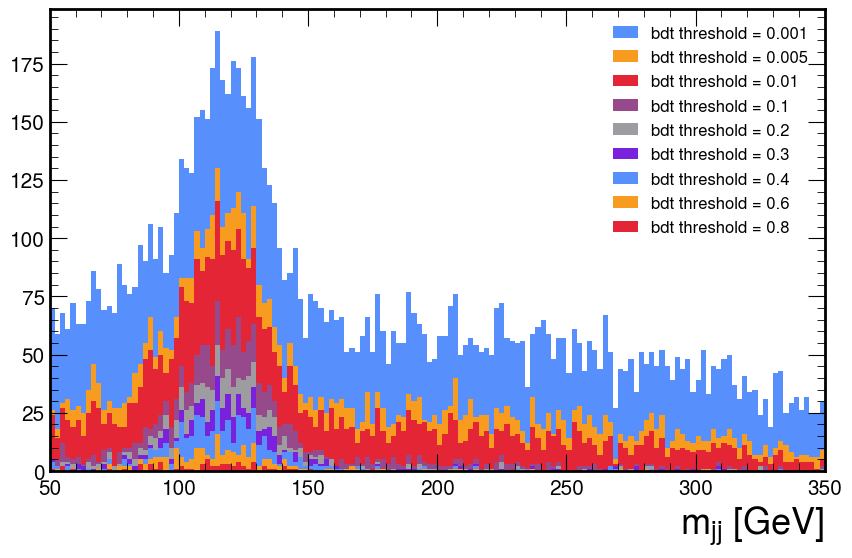

In [194]:
import matplotlib.colors as colors
import matplotlib

sigMu_hist = hists[1]
# hist_3d.project("dijetmass", "dijetpt").plot2d(norm=matplotlib.colors.LogNorm())
# hist_3d.project("bdt").plot1d()

# for i, axis in enumerate(hist_2d.axes):
#     fig, ax = plt.subplots(figsize=(10, 6)) 
#     hist_2d.project(axis.name).plot1d(ax=ax, fill=True, label=axis.name, color=plt.colormaps['Set1'](i), flow='none')
#     plt.show()
fig, ax = plt.subplots(figsize=(10, 6)) 
bdt_values = [0.001, 0.005, 0.01, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]
for i in bdt_values:
    x = complex(0, i)
    sigMu_hist[:, 100j:300j:sum, x:1.0j:sum, 50j::sum].plot1d(ax=ax, fill=True, label=f"bdt threshold = {i}", flow='none')
# ax.set_yscale('log')
plt.legend(fontsize=12)
plt.show()

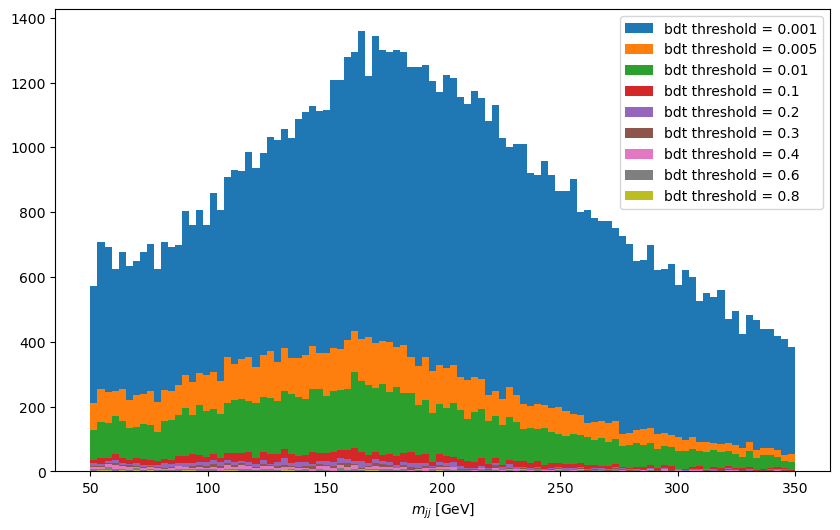

In [43]:
hist_3d = out['dijet_hist']
# mass_projection = hist_3d[:, sum, 0j:0.1j:sum].plot1d()
# bdt_projection = hist_3d[sum, sum, :].plot1d()


back_hist = hists[2]
# hist_3d.project("dijetmass", "dijetpt").plot2d(norm=matplotlib.colors.LogNorm())
# hist_3d.project("bdt").plot1d()

# for i, axis in enumerate(hist_2d.axes):
#     fig, ax = plt.subplots(figsize=(10, 6)) 
#     hist_2d.project(axis.name).plot1d(ax=ax, fill=True, label=axis.name, color=plt.colormaps['Set1'](i), flow='none')
#     plt.show()
fig, ax = plt.subplots(figsize=(10, 6)) 
bdt_values = [0.001, 0.005, 0.01, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]
for i in bdt_values:
    x = complex(0, i)
    back_hist[:, 50j:300j:sum, x:1.0j:sum, 50j::sum].plot1d(ax=ax, fill=True, label=f"bdt threshold = {i}", flow='none')
# ax.set_yscale('log')
plt.legend()
plt.show()


In [44]:
# distributed running
import time
from datetime import datetime
from distributed import Client
from lpcjobqueue import LPCCondorCluster
from coffea.processor import SimpleCheckpointer

cluster = LPCCondorCluster(ship_env=True, log_directory="/uscms/home/ccosby/logs")
cluster.adapt(minimum=1, maximum=100)
client = Client(cluster)

# set up checkpoints
datestring = datetime.now().strftime('%Y%m%d%H')
checkpointer = SimpleCheckpointer(checkpoint_dir=f'checkpoints/{datestring}', verbose=True)

client
cluster

Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://131.225.191.83:10016,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


2026-03-08 03:58:29,400 - distributed.scheduler - ERROR - Task BDTTestProcessor-2f180e7e9bfd2a0e966a53d394c62f61 marked as failed because 4 workers died while trying to run it


In [96]:
# set up runner
client.wait_for_workers(1)
runner = processor.Runner(
     #executor = processor.FuturesExecutor(),
     executor = processor.DaskExecutor(client=client),
     savemetrics=True,
     schema=NanoAODSchema,
     # maxchunks=1, # for testing
     chunksize=100000,
     skipbadfiles=True,
     align_clusters=False,
     # checkpointer = checkpointer
)
from coffea.processor.executor import FileMeta
output, metrics = runner('SingleMuon24_replicas_info.json', processor_instance=BDTTestProcessor(model))

/usr/local/lib/python3.10/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 21.63 
MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119322/119322 [ 1:47:32 < 0:00:00 | ? chunk/s ]

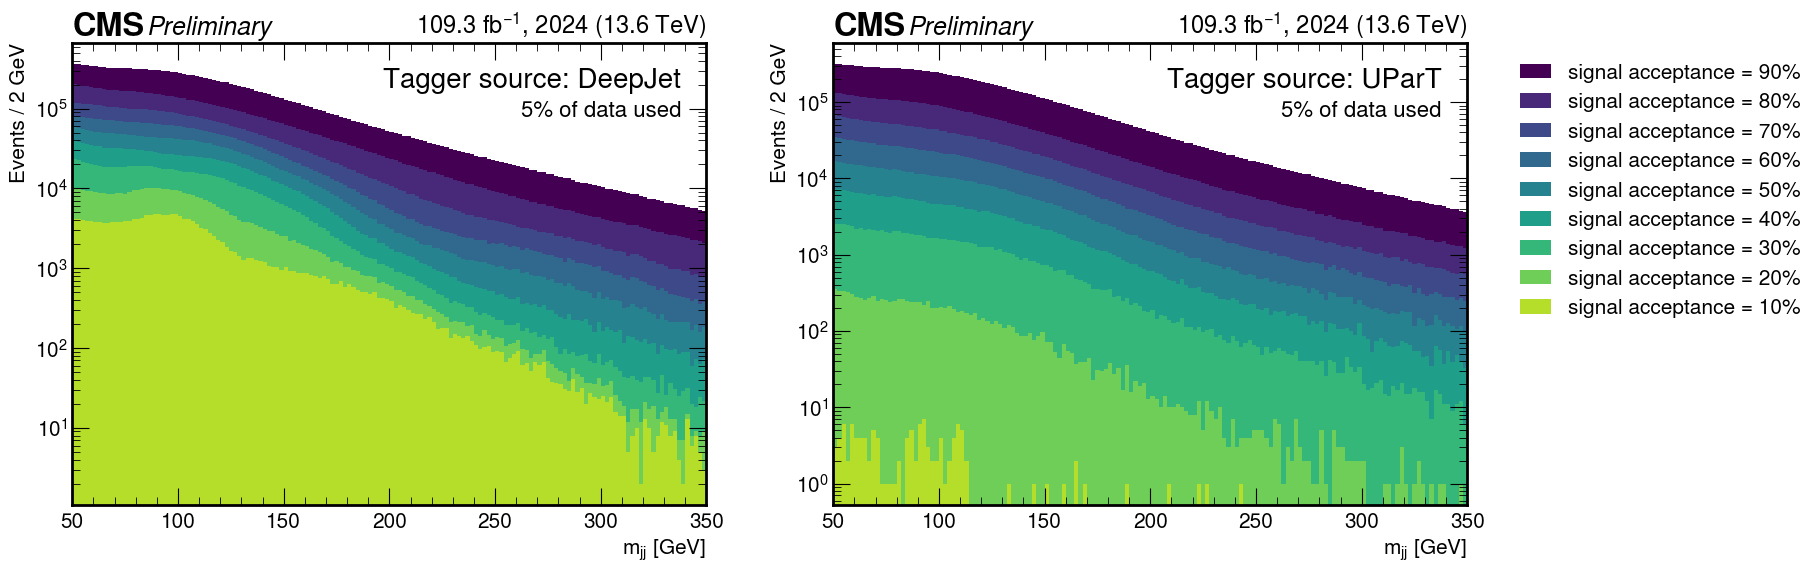

In [65]:
import mplhep
import matplotlib as mpl
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
mplhep.style.use("CMS") 

deepjet_bdt_values = [0.04, 0.13, 0.26, 0.35, 0.42, 0.49, 0.56, 0.61, 0.64]
upart_bdt_values = [0.08, 0.25, 0.45, 0.62, 0.75, 0.84, 0.91, 0.96, 0.98]
signal_acceptance = [90, 80, 70, 60, 50, 40, 30, 20, 10]
# deepjet_bdt_values = [0.13, 0.26, 0.35, 0.42, 0.49, 0.56, 0.61, 0.64, 0.66]
# upart_bdt_values = [0.25, 0.45, 0.62, 0.75, 0.84, 0.91, 0.96, 0.98, 0.99]
# signal_acceptance = [80, 70, 60, 50, 40, 30, 20, 10, 5]
font_size = 15
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
plt.rcParams['axes.xmargin'] = 0

fig, ax = plt.subplots(1, 2, figsize=(18, 6)) 
# bdt_values = [0.4, 0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
taggers = ["DeepJet", "UParT"]
for j, tagger in enumerate(taggers):
# load both histograms
    hist_pkl = None
    with open(f'20percentHist2026030803_{tagger}_BDT.pkl', 'rb') as f:
        hist_pkl = pickle.load(f)
    hist_4d = hist_pkl['dijet_hist']

    if tagger == "DeepJet":
        bdt_values = deepjet_bdt_values
    else:
        bdt_values = upart_bdt_values

    for c_idx, i in enumerate[float](bdt_values):
        x = complex(0, i)
        hist_4d[::1j, 50j::sum, x:1.0j:sum, 0j::sum].plot1d(ax=ax[j], fill=True, label=f"signal acceptance = {signal_acceptance[c_idx]}%", flow='none', color=plt.colormaps['viridis'](c_idx/len(bdt_values)))
    ax[j].set_xlabel("$m_{jj}$ [GeV]", fontsize = font_size)
    ax[j].set_ylabel("Events / 2 GeV", fontsize = font_size)


    ax[j].text(0.96, 0.89, f'Tagger source: {tagger}', fontsize=20, horizontalalignment='right', verticalalignment='bottom', transform=ax[j].transAxes)
    ax[j].text(0.96, 0.83, '5% of data used', fontsize=16, horizontalalignment='right', verticalalignment='bottom', transform=ax[j].transAxes)
    mplhep.cms.label('Preliminary', data=True, year='2024', lumi=109.32, com=13.6, lumi_format='{0:.1f}', fontsize=18, ax=ax[j])

ax[1].legend(fontsize = font_size, bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
plt.show()

In [25]:
iterative_run = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=NanoAODSchema,
    # maxchunks=3,
    savemetrics=True,
)

hists_signal = {}
taggers = ["DeepJet", "UParT"]

for tagger in taggers:
    model = pickle.load(open(f"models/bdt_model_{tagger}_noDijet_info.pkl", "rb"))
    out, metrics = iterative_run(
        signal_fileset,
        processor_instance=BDTTestProcessor(model, tagger),
    )
    hists_signal[tagger] = out['dijet_hist']

Output()

Output()

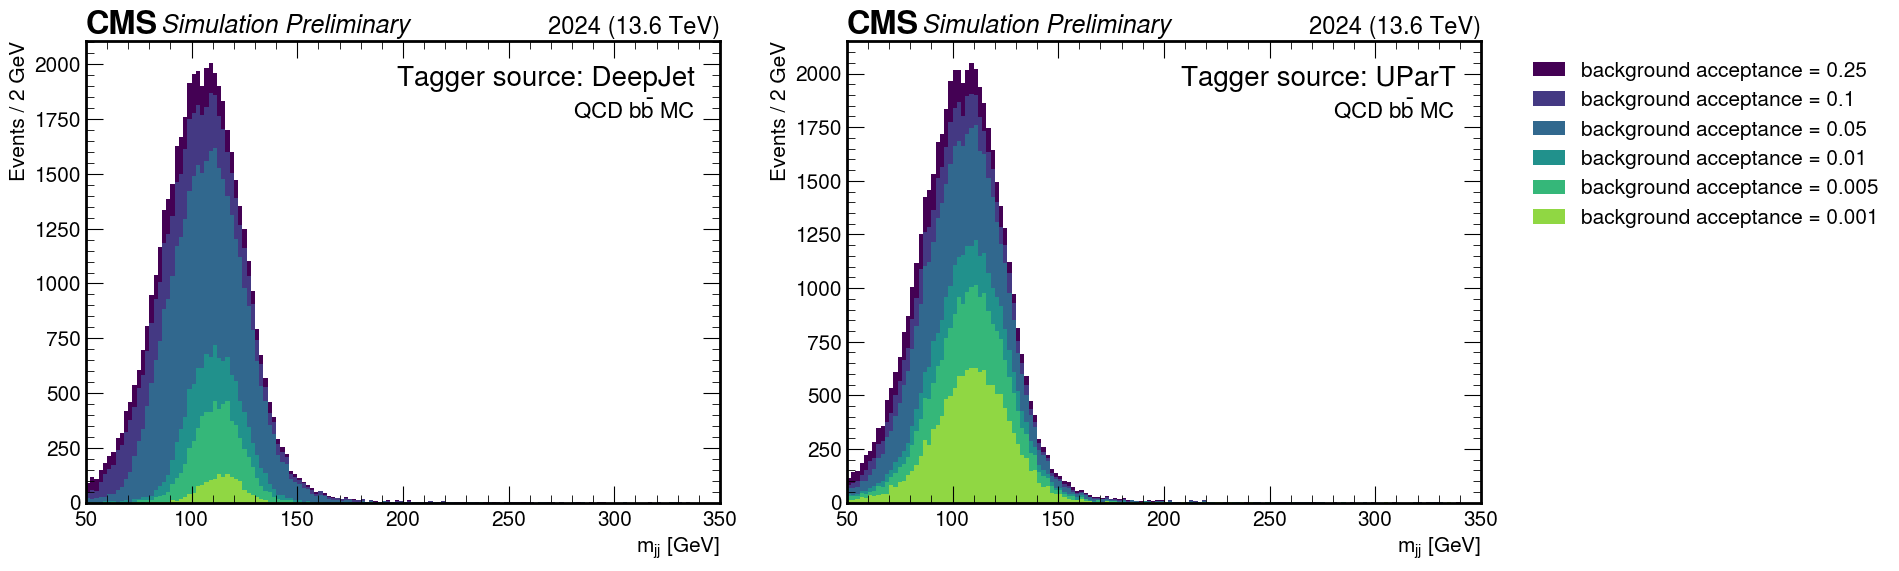

In [74]:
font_size = 15
fig, ax = plt.subplots(1, 2, figsize=(18, 6)) 
deepjet_bdt_values = [0.02, 0.06, 0.22, 0.58, 0.62, 0.67]
upart_bdt_values = [0.02, 0.09, 0.22, 0.68, 0.79, 0.92]
background_acceptance = [0.25, 0.1, 0.05, 0.01, 0.005, 0.001]

# bdt_values = [0.4, 0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
taggers = ["DeepJet", "UParT"]
for j, tagger in enumerate(taggers):
# load both histograms
    hist_4d = hists_signal[tagger]
    if tagger == "DeepJet":
        bdt_values = deepjet_bdt_values
    else:
        bdt_values = upart_bdt_values
    for c_idx, i in enumerate[float](bdt_values):
        x = complex(0, i)
        hist_4d[::1j, 0j::sum, x:1.0j:sum, 0j::sum].plot1d(ax=ax[j], fill=True, label=f"background acceptance = {background_acceptance[c_idx]}", flow='none', color=plt.colormaps['viridis'](c_idx/len(bdt_values)))
    ax[j].set_xlabel("$m_{jj}$ [GeV]", fontsize = font_size)
    ax[j].set_ylabel("Events / 2 GeV", fontsize = font_size)


    ax[j].text(0.96, 0.89, f'Tagger source: {tagger}', fontsize=20, horizontalalignment='right', verticalalignment='bottom', transform=ax[j].transAxes)
    # ax[j].text(0.96, 0.76, '3 million Higgs to $b\\bar{b}$ events\nHLT_Mu10_Barrel_L1HP11_IP6 required', fontsize=16, horizontalalignment='right', verticalalignment='bottom', transform=ax[j].transAxes)
    ax[j].text(0.96, 0.82, 'QCD $b\\bar{b}$ MC', fontsize=16, horizontalalignment='right', verticalalignment='bottom', transform=ax[j].transAxes)
    mplhep.cms.label("Preliminary", data=False, year='2024', com=13.6, fontsize=18, ax=ax[j])

ax[1].legend(fontsize = font_size, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [66]:
hist_pkl = None
with open(f'20percentHist2026030803_DeepJet_BDT.pkl', 'rb') as f:
    hist_pkl = pickle.load(f)
hist_4d = hist_pkl['dijet_hist']
for i in range(100):
    x = complex(0, i/100)
    remaining = hist_4d[90j:140j:sum, 0j::sum, x:1.0j:sum, 0j::sum]
    total = hist_4d[90j:140j:sum, 0j::sum, 0j:1.0j:sum, 0j::sum]
    print(f'bdt val: {i/100},  surviving : {round(remaining/total, 4)}')

bdt val: 0.0,  surviving : 1.0
bdt val: 0.01,  surviving : 0.3295
bdt val: 0.02,  surviving : 0.2195
bdt val: 0.03,  surviving : 0.1633
bdt val: 0.04,  surviving : 0.1346
bdt val: 0.05,  surviving : 0.1166
bdt val: 0.06,  surviving : 0.1039
bdt val: 0.07,  surviving : 0.0951
bdt val: 0.08,  surviving : 0.0885
bdt val: 0.09,  surviving : 0.0833
bdt val: 0.1,  surviving : 0.079
bdt val: 0.11,  surviving : 0.0752
bdt val: 0.12,  surviving : 0.0719
bdt val: 0.13,  surviving : 0.0688
bdt val: 0.14,  surviving : 0.066
bdt val: 0.15,  surviving : 0.0635
bdt val: 0.16,  surviving : 0.0612
bdt val: 0.17,  surviving : 0.059
bdt val: 0.18,  surviving : 0.0571
bdt val: 0.19,  surviving : 0.0552
bdt val: 0.2,  surviving : 0.0535
bdt val: 0.21,  surviving : 0.0518
bdt val: 0.22,  surviving : 0.0501
bdt val: 0.23,  surviving : 0.0486
bdt val: 0.24,  surviving : 0.047
bdt val: 0.25,  surviving : 0.0455
bdt val: 0.26,  surviving : 0.0441
bdt val: 0.27,  surviving : 0.0427
bdt val: 0.28,  surviving : 0.

In [ ]:
# #bdt values for 90, 80, 70, 60, 50, 40, 30, 20, 10, 5, 1 #### signal acceptance
# deepjet_bdt_values = [0.04, 0.13, 0.26, 0.35, 0.42, 0.49, 0.56, 0.61, 0.64, 0.66]
# upart_bdt_values = [0.08, 0.25, 0.45, 0.62, 0.75, 0.84, 0.91, 0.96, 0.98, 0.99]

#bdt values for 0.25, 0.1, 0.05, 0.01, 0.005, 0.001### background acceptance
deepjet_bdt_values = [0.02, 0.06, 0.22, 0.58, 0.62, 0.67]
upart_bdt_values = [0.02, 0.09, 0.22, 0.68, 0.79, 0.92]

In [67]:
hist_pkl = None
with open(f'20percentHist2026030803_UParT_BDT.pkl', 'rb') as f:
    hist_pkl = pickle.load(f)
hist_4d = hist_pkl['dijet_hist']
for i in range(100):
    x = complex(0, i/100)
    remaining = hist_4d[90j:140j:sum, 0j::sum, x:1.0j:sum, 0j::sum]
    total = hist_4d[90j:140j:sum, 0j::sum, 0j:1.0j:sum, 0j::sum]
    print(f'bdt val: {i/100},  surviving : {round(remaining/total, 4)}')

bdt val: 0.0,  surviving : 1.0
bdt val: 0.01,  surviving : 0.3555
bdt val: 0.02,  surviving : 0.252
bdt val: 0.03,  surviving : 0.2057
bdt val: 0.04,  surviving : 0.1768
bdt val: 0.05,  surviving : 0.1563
bdt val: 0.06,  surviving : 0.1403
bdt val: 0.07,  surviving : 0.1273
bdt val: 0.08,  surviving : 0.1161
bdt val: 0.09,  surviving : 0.1067
bdt val: 0.1,  surviving : 0.0992
bdt val: 0.11,  surviving : 0.0924
bdt val: 0.12,  surviving : 0.0865
bdt val: 0.13,  surviving : 0.0814
bdt val: 0.14,  surviving : 0.0768
bdt val: 0.15,  surviving : 0.0725
bdt val: 0.16,  surviving : 0.0686
bdt val: 0.17,  surviving : 0.065
bdt val: 0.18,  surviving : 0.0618
bdt val: 0.19,  surviving : 0.0586
bdt val: 0.2,  surviving : 0.0556
bdt val: 0.21,  surviving : 0.0529
bdt val: 0.22,  surviving : 0.0506
bdt val: 0.23,  surviving : 0.0486
bdt val: 0.24,  surviving : 0.0466
bdt val: 0.25,  surviving : 0.0448
bdt val: 0.26,  surviving : 0.0431
bdt val: 0.27,  surviving : 0.0415
bdt val: 0.28,  surviving : 

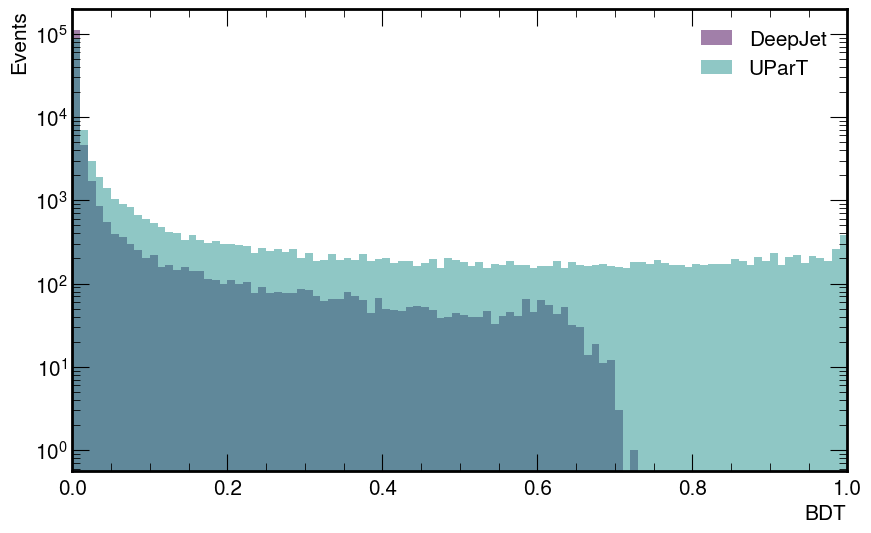

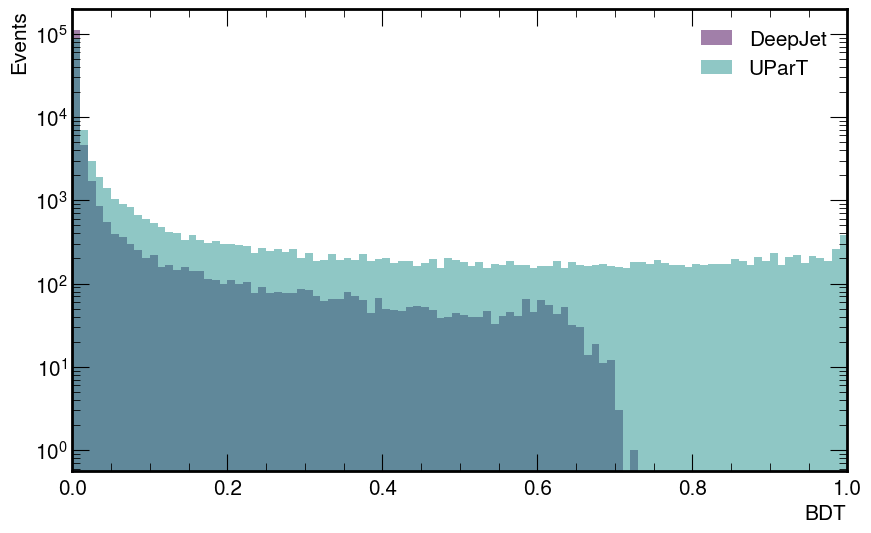

In [24]:
#noramlized BDT distributions for signal and background

fig, ax = plt.subplots(figsize=(10, 6)) 
taggers = ["DeepJet", "UParT"]
for i, tagger in enumerate(taggers):
    # hist_pkl_bkg = None
    # with open(f'20percentHist2026030803_{tagger}_BDT.pkl', 'rb') as f:
    #     hist_pkl_bkg = pickle.load(f)
    hist_bkg = qcd_hist[tagger]

    hist_bkg[::sum, 0j::sum, ::2j, 0j::sum].plot1d(ax=ax, fill=True, label=f"{tagger}", alpha=0.5, flow='none', color=plt.colormaps['viridis'](i/len(taggers)))  

ax.set_yscale('log')
ax.set_xlabel("$BDT$", fontsize = font_size)
ax.set_ylabel("Events",fontsize = font_size)
ax.legend(fontsize = font_size)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6)) 
taggers = ["DeepJet", "UParT"]
for i, tagger in enumerate(taggers):
    hist_sig = hists_signal[tagger]
    hist_sig[::sum, 0j::sum, ::2j, 0j::sum].plot1d(ax=ax, fill=True, label=f"{tagger}", alpha=0.5, flow='none', color=plt.colormaps['viridis'](i/len(taggers)))  

ax.set_yscale('log')
ax.set_xlabel("$BDT$", fontsize = font_size)
ax.set_ylabel("Events",fontsize = font_size)
ax.legend(fontsize = font_size, loc='upper right')
plt.show()



/tmp/ipykernel_1149/1781762140.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  sensitivity = sig_yield / np.sqrt(bkg_yield)
/tmp/ipykernel_1149/1781762140.py:18: RuntimeWarning: invalid value encountered in scalar divide
  sensitivity = sig_yield / np.sqrt(bkg_yield)


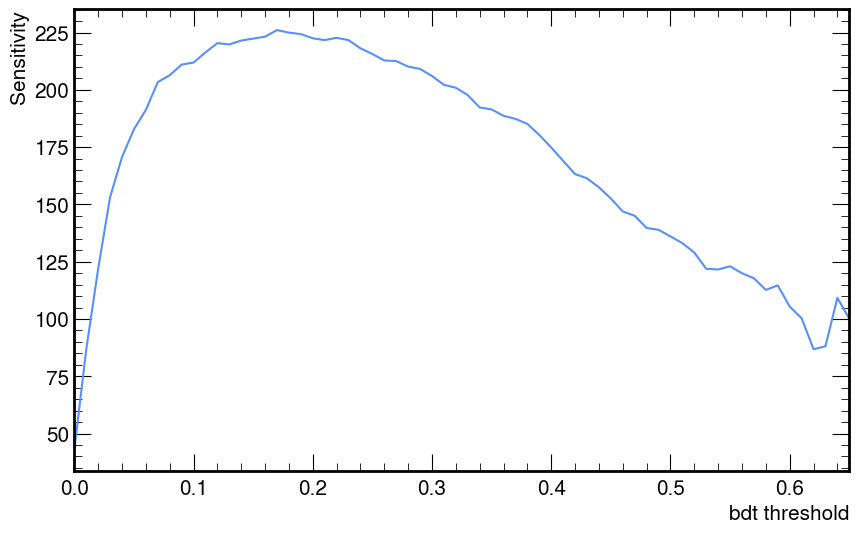

In [31]:
#sensitivity scans
# bdt values to check
bdt_points = range(0, 100, 1)
bdt_points = [i/100 for i in bdt_points]
# signal and background histograms
hist_sig = hists_signal['DeepJet']
hist_pkl_bkg = None
with open('20percentHist2026030803_DeepJet_BDT.pkl', 'rb') as f:
    hist_pkl_bkg = pickle.load(f)
hist_bkg = hist_pkl_bkg['dijet_hist']
hist_bkg = qcd_hist['DeepJet']
# sensitivity scan
sensitivities = []
for bdt_threshold in bdt_points:
    x = complex(0, bdt_threshold)
    sig_yield = hist_sig[90j:140j:sum, 50j::sum, x:1.0j:sum, 0j::sum]
    bkg_yield = 20 * hist_bkg[90j:140j:sum, 50j::sum, x:1.0j:sum, 0j::sum]
    sensitivity = sig_yield / np.sqrt(bkg_yield)
    sensitivities.append(sensitivity)

# plot sensitivity scan
plt.figure(figsize=(10, 6))
plt.plot(bdt_points, sensitivities)
plt.xlabel('bdt threshold', fontsize = font_size)
plt.ylabel('Sensitivity', fontsize = font_size)

plt.show()

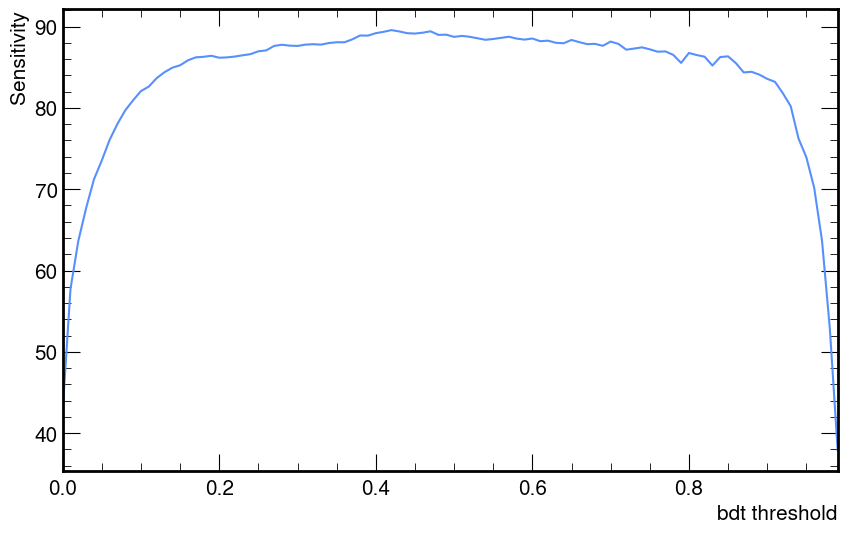

In [32]:
#sensitivity scans
# bdt values to check
bdt_points = range(0, 100, 1)
bdt_points = [i/100 for i in bdt_points]
# signal and background histograms
hist_sig = hists_signal['UParT']
hist_pkl_bkg = None
with open('20percentHist2026030803_UParT_BDT.pkl', 'rb') as f:
    hist_pkl_bkg = pickle.load(f)
hist_bkg = hist_pkl_bkg['dijet_hist']
hist_bkg = qcd_hist['UParT']
# sensitivity scan
sensitivities = []
for bdt_threshold in bdt_points:
    x = complex(0, bdt_threshold)
    sig_yield = hist_sig[90j:140j:sum, 50j::sum, x:1.0j:sum, 0j::sum]
    bkg_yield = 20 * hist_bkg[90j:140j:sum, 50j::sum, x:1.0j:sum, 0j::sum]
    sensitivity = sig_yield / np.sqrt(bkg_yield)
    sensitivities.append(sensitivity)

# plot sensitivity scan
plt.figure(figsize=(10, 6))
plt.plot(bdt_points, sensitivities)
plt.xlabel('bdt threshold', fontsize = font_size)
plt.ylabel('Sensitivity', fontsize = font_size)

plt.show()
    